In [1]:
import os
import torch
import numpy as np
import urllib.request
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ==========================================
# 0. CONFIGURATION
# ==========================================
CACHE_DIR = '/kaggle/working/cache_quickdraw'
BATCH_SIZE = 256
EPOCHS = 100
LR = 0.002

# ==========================================
# 1. BINARIZATION [-1, +1] VÀ QAT (STE TRICK FOR XNOR)
# ==========================================
# 1A. Ép nhị phân [-1, +1] cho Activation (Output của các lớp)
class BinaryActivationBipolar(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        # BNN chuẩn: x > 0 -> +1.0, x <= 0 -> -1.0
        return torch.where(input > 0, torch.tensor(1.0, device=input.device), torch.tensor(-1.0, device=input.device))

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # STE Trick: Giữ nguyên gradient khi |x| <= 1
        grad_input[input.abs() > 1] = 0
        return grad_input

def binary_step(x):
    return BinaryActivationBipolar.apply(x)

# 1B. Ép nhị phân [-1, +1] cho Trọng số (Weights) chuẩn Cổng XNOR
class QAT_Conv2d(nn.Conv2d):
    def forward(self, input):
        # Biến trọng số float thành -1.0 và +1.0
        w_bin = torch.where(self.weight > 0, torch.tensor(1.0, device=self.weight.device), torch.tensor(-1.0, device=self.weight.device))
        w_ste = self.weight + (w_bin - self.weight).detach()
        return F.conv2d(input, w_ste, self.bias, self.stride, self.padding, self.dilation, self.groups)

class QAT_Linear(nn.Linear):
    def forward(self, input):
        # Biến trọng số float thành -1.0 và +1.0
        w_bin = torch.where(self.weight > 0, torch.tensor(1.0, device=self.weight.device), torch.tensor(-1.0, device=self.weight.device))
        w_ste = self.weight + (w_bin - self.weight).detach()
        return F.linear(input, w_ste, self.bias)

# ==========================================
# 2. bDSCNN ARCHITECTURE (QAT ENABLED - QUICK DRAW)
# ==========================================
class bDSCNN(nn.Module):
    def __init__(self):
        super(bDSCNN, self).__init__()
        
        # 1. MCP Layer
        self.mcp = QAT_Conv2d(1, 3, kernel_size=4, stride=2, padding=0, bias=False)
        self.bn_mcp = nn.BatchNorm2d(3)
        
        # 2. DSC Layer = Depthwise (DW) + Pointwise (PW)
        self.dw = QAT_Conv2d(3, 3, kernel_size=3, stride=1, padding=0, groups=3, bias=False)
        self.pw = QAT_Conv2d(3, 18, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn_pw = nn.BatchNorm2d(18)
        
        # 3. FC1 Layer
        self.fc1 = QAT_Linear(3042, 64, bias=False)
        self.bn_fc1 = nn.BatchNorm1d(64)
        
        # 4. FC2 Layer (Đầu ra 10 Classes)
        self.fc2 = QAT_Linear(64, 10, bias=False)
        self.bn_fc2 = nn.BatchNorm1d(10)

    def forward(self, img):
        x = self.mcp(img)
        x = binary_step(self.bn_mcp(x)) 
        
        x = self.dw(x) 
        x = self.pw(x)
        x = binary_step(self.bn_pw(x)) 
        
        x = x.view(x.size(0), -1) 
        
        x = self.fc1(x)
        x = binary_step(self.bn_fc1(x)) 
        
        x = self.fc2(x)
        x = self.bn_fc2(x) 
        return x

# ==========================================
# 3. DATA PROCESSING (QUICK DRAW!)
# ==========================================
def prepare_quickdraw_data(num_samples_per_class=15000):
    classes = ['apple', 'clock', 'star', 'bicycle', 'cookie', 
               'moon', 'sword', 'tree', 't-shirt', 'lightning']
    
    X_imgs, Y_labels = [], []
    
    if not os.path.exists(CACHE_DIR): 
        os.makedirs(CACHE_DIR)
    
    print(">>> Đang tải và xử lý dữ liệu Quick, Draw!...")
    for label_idx, cls_name in enumerate(classes):
        url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{cls_name}.npy"
        file_path = f"{CACHE_DIR}/{cls_name}.npy"
        
        if not os.path.exists(file_path):
            print(f"    Tải class '{cls_name}'...")
            urllib.request.urlretrieve(url, file_path)
            
        data = np.load(file_path)[:num_samples_per_class]
        data_2d = data.reshape(-1, 28, 28)
        
        # Padding viền đen (giá trị 0 trước binarization)
        data_padded = np.pad(data_2d, ((0,0), (2,2), (2,2)), 'constant', constant_values=0)
        
        # SỬA: Ép nhị phân về Bipolar {-1.0, +1.0}
        # Nét vẽ (sáng > 127) thành +1.0, nền (đen <= 127) thành -1.0
        data_bin = np.where(data_padded > 127, 1.0, -1.0)
        
        X_imgs.append(data_bin)
        Y_labels.extend([label_idx] * num_samples_per_class)
        
    X_imgs = np.expand_dims(np.concatenate(X_imgs, axis=0), axis=1).astype(np.float32)
    Y_labels = np.array(Y_labels, dtype=np.int64)
    
    print(f"✅ Đã tạo xong {len(X_imgs)} mẫu dữ liệu 32x32 Bipolar [-1, +1] (10 Classes)!")
    return X_imgs, Y_labels

# ==========================================
# 4. TRAINING PIPELINE
# ==========================================
class QuickDrawDataset(Dataset):
    def __init__(self, X, Y):
        self.X, self.Y = X, Y
    def __len__(self): 
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.Y[idx])

X_data, Y_data = prepare_quickdraw_data()
X_tr, X_te, Y_tr, Y_te = train_test_split(X_data, Y_data, test_size=0.2, random_state=42)

trainloader = DataLoader(QuickDrawDataset(X_tr, Y_tr), batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(QuickDrawDataset(X_te, Y_te), batch_size=1024, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = bDSCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

print(f">>> Bắt đầu Training bDSCNN (QAT [-1, +1]) 10 Classes trên {device}...")
best_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
    
    scheduler.step()
    
    model.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    
    acc = 100 * correct / total
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Test Acc: {acc:.2f}%")
    
    if acc > best_acc: 
        best_acc = acc
        torch.save(model.state_dict(), '/kaggle/working/best_qat_quickdraw_model.pth')

print("====================================================")
print(f"🏆 Độ chính xác cao nhất (Best Accuracy): {best_acc:.2f}%")
print("🔥 Đã lưu 'best_qat_quickdraw_model.pth'. Sẵn sàng trích xuất sang FPGA!")
print("====================================================")

>>> Đang tải và xử lý dữ liệu Quick, Draw!...
    Tải class 'apple'...
    Tải class 'clock'...
    Tải class 'star'...
    Tải class 'bicycle'...
    Tải class 'cookie'...
    Tải class 'moon'...
    Tải class 'sword'...
    Tải class 'tree'...
    Tải class 't-shirt'...
    Tải class 'lightning'...
✅ Đã tạo xong 150000 mẫu dữ liệu 32x32 Bipolar [-1, +1] (10 Classes)!
>>> Bắt đầu Training bDSCNN (QAT [-1, +1]) 10 Classes trên cpu...
Epoch 01/100 | Test Acc: 78.09%
Epoch 02/100 | Test Acc: 34.02%
Epoch 03/100 | Test Acc: 80.33%
Epoch 04/100 | Test Acc: 78.08%
Epoch 05/100 | Test Acc: 75.44%
Epoch 06/100 | Test Acc: 31.73%
Epoch 07/100 | Test Acc: 81.51%
Epoch 08/100 | Test Acc: 83.30%
Epoch 09/100 | Test Acc: 83.60%
Epoch 10/100 | Test Acc: 84.83%
Epoch 11/100 | Test Acc: 85.04%
Epoch 12/100 | Test Acc: 83.05%
Epoch 13/100 | Test Acc: 83.16%
Epoch 14/100 | Test Acc: 84.31%
Epoch 15/100 | Test Acc: 83.72%
Epoch 16/100 | Test Acc: 78.55%
Epoch 17/100 | Test Acc: 79.64%
Epoch 18/100 | Tes

🚀 KHỞI ĐỘNG TRÍCH XUẤT 10 MẪU GOLDEN VECTORS CHO TESTBENCH RTL...
✅ Mẫu 0: True = star (Class 2), AI Pred = star (Class 2)
✅ Mẫu 1: True = moon (Class 5), AI Pred = moon (Class 5)
✅ Mẫu 2: True = clock (Class 1), AI Pred = clock (Class 1)
✅ Mẫu 3: True = lightning (Class 9), AI Pred = lightning (Class 9)
✅ Mẫu 4: True = clock (Class 1), AI Pred = clock (Class 1)
✅ Mẫu 5: True = star (Class 2), AI Pred = star (Class 2)
✅ Mẫu 6: True = t-shirt (Class 8), AI Pred = t-shirt (Class 8)
✅ Mẫu 7: True = clock (Class 1), AI Pred = clock (Class 1)
✅ Mẫu 8: True = cookie (Class 4), AI Pred = cookie (Class 4)
✅ Mẫu 9: True = star (Class 2), AI Pred = star (Class 2)


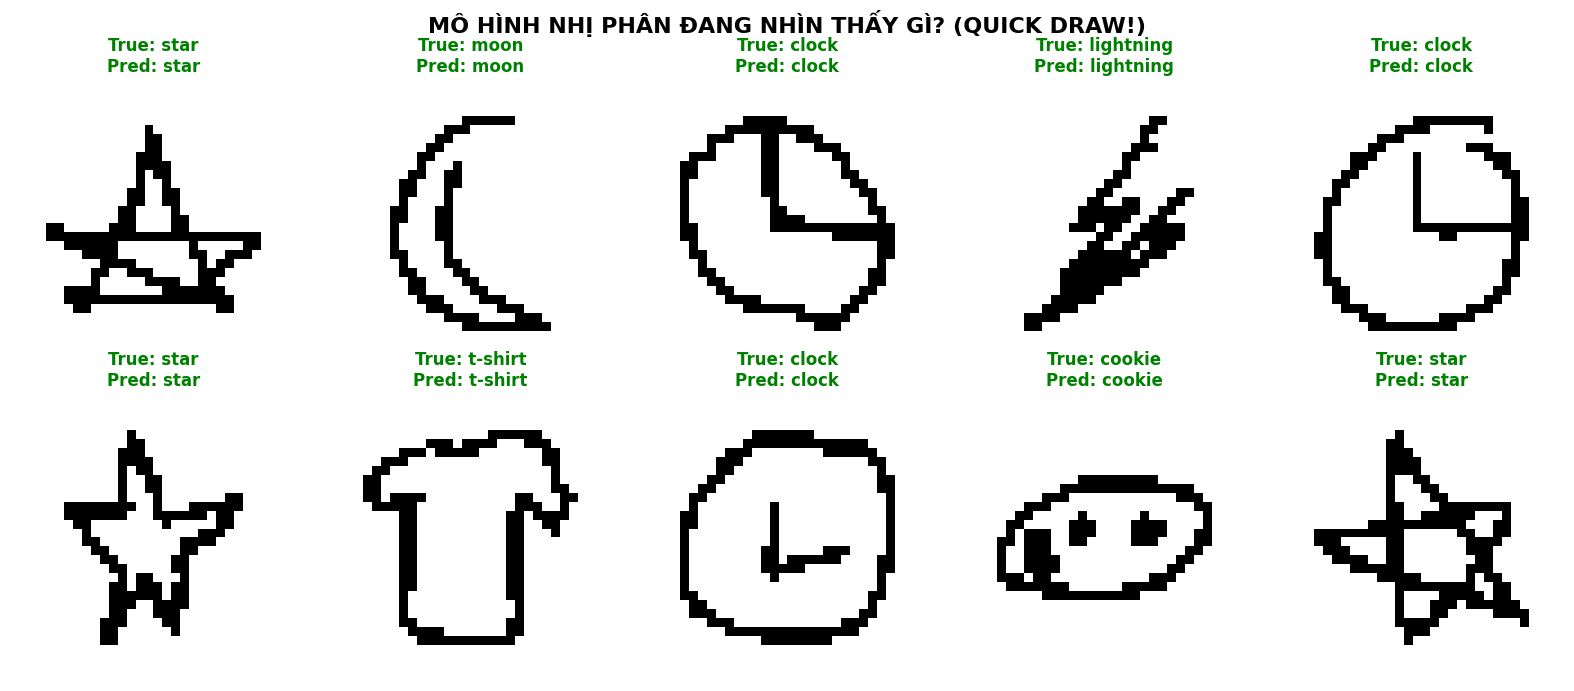

✅ Đã lưu xong chuỗi bit và metadata tại: /kaggle/working/quickdraw_rtl_vectors
🎁 Đã đóng gói thành file: /kaggle/working/quickdraw_rtl_vectors.zip. Hãy tải file này về để nạp xuống Quartus!


In [2]:
import os
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

def verify_and_export_quickdraw(model, X_te, Y_te, export_dir="/kaggle/working/quickdraw_rtl_vectors", num_samples=10):
    if not os.path.exists(export_dir):
        os.makedirs(export_dir)
        
    print(f"🚀 KHỞI ĐỘNG TRÍCH XUẤT {num_samples} MẪU GOLDEN VECTORS CHO TESTBENCH RTL...")
    print("====================================================")
    
    # Bốc ngẫu nhiên 10 mẫu để test
    np.random.seed(2026) # Cố định seed để dễ debug
    indices = np.random.choice(len(X_te), num_samples, replace=False)
    
    device = next(model.parameters()).device
    sample_imgs = torch.tensor(X_te[indices]).float().to(device)
    true_labels = Y_te[indices]
    
    # Tên của 10 class Quick, Draw!
    class_map = ['apple', 'clock', 'star', 'bicycle', 'cookie', 
                 'moon', 'sword', 'tree', 't-shirt', 'lightning']
    
    # --------------------------------------------------------
    # 🔥 ÉP TRỌNG SỐ VỀ [-1.0, +1.0] ĐỂ KHỚP VỚI QAT BIPOLAR
    # --------------------------------------------------------
    model.eval()
    with torch.no_grad():
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                # Biến trọng số float thành nhị phân Bipolar {-1.0, +1.0}
                binary_w = torch.where(module.weight.data > 0, 
                                       torch.tensor(1.0, device=device), 
                                       torch.tensor(-1.0, device=device))
                module.weight.copy_(binary_w)
                
        # Chạy suy luận (Inference)
        outputs = model(sample_imgs)
        preds = outputs.argmax(1).cpu().numpy()
        
    # --------------------------------------------------------
    # PLOT ẢNH LÊN MÀN HÌNH VÀ EXPORT TEST VECTORS
    # --------------------------------------------------------
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle("MÔ HÌNH NHỊ PHÂN ĐANG NHÌN THẤY GÌ? (QUICK DRAW!)", fontsize=16, fontweight='bold')
    
    for i, (idx, ax) in enumerate(zip(indices, axes.flatten())):
        true_name = class_map[true_labels[i]]
        pred_name = class_map[preds[i]]
        
        # Mảng numpy 2D (32x32) gốc đang mang giá trị Bipolar {-1.0, +1.0}
        img_bipolar = sample_imgs[i].cpu().numpy().squeeze()
        
        # Chuyển Bipolar {-1.0, +1.0} sang bit nhị phân {0, 1} cho Hardware và Plot
        # Nếu pixel > 0 (nét vẽ) -> 1, ngược lại (nền) -> 0
        img_bits = np.where(img_bipolar > 0, 1, 0)
        
        title_color = 'green' if true_labels[i] == preds[i] else 'red'
        
        # 1. Vẽ hình lên lưới (dùng gray_r để nền trắng, nét đen)
        ax.imshow(img_bits, cmap='gray_r')
        ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=title_color, fontweight='bold')
        ax.axis('off')
        
        # 2. Đổ dữ liệu xuống file cho phần cứng
        print(f"✅ Mẫu {i}: True = {true_name} (Class {true_labels[i]}), AI Pred = {pred_name} (Class {preds[i]})")
        
        # Lưu 1024 bit điểm ảnh dạng {0, 1} (mỗi bit 1 dòng để dễ chạy $readmemb trong Verilog)
        with open(f"{export_dir}/test_img_{i}.txt", "w") as f:
            for row in img_bits:
                for pixel in row:
                    f.write(f"{pixel}\n")
                    
        # Lưu nhãn dự đoán để Testbench tự động Check (Self-checking Testbench)
        with open(f"{export_dir}/test_meta_{i}.txt", "w") as f:
            f.write(f"{preds[i]}\n") 
            
    plt.tight_layout()
    plt.show()
    
    print("====================================================")
    print(f"✅ Đã lưu xong chuỗi bit và metadata tại: {export_dir}")
    
    # --------------------------------------------------------
    # NÉN THÀNH FILE ZIP
    # --------------------------------------------------------
    zip_filename = "/kaggle/working/quickdraw_rtl_vectors"
    shutil.make_archive(zip_filename, 'zip', export_dir)
    print(f"🎁 Đã đóng gói thành file: {zip_filename}.zip. Hãy tải file này về để nạp xuống Quartus!")

# Gọi hàm
verify_and_export_quickdraw(model, X_te, Y_te, num_samples=10)

In [3]:
import os
import math
import shutil
import numpy as np
import torch

def export_quickdraw_to_hex(model, export_dir="/kaggle/working/fpga_hex_quickdraw"):
    if not os.path.exists(export_dir):
        os.makedirs(export_dir)
        
    print(f"🚀 Đang trích xuất trọng số Bipolar [-1, +1] xuống Hex: {export_dir}...")

    def get_binary_weights(tensor):
        # Trọng số > 0 (+1.0) ánh xạ thành bit 1
        # Trọng số <= 0 (-1.0) ánh xạ thành bit 0 cho cổng XNOR
        return np.where(tensor.cpu().detach().numpy() > 0, 1, 0)
        
    def calc_bn_thresholds(bn_layer, num_inputs):
        """
        Chuyển đổi Ngưỡng BatchNorm sang miền Popcount XNOR
        """
        mu = bn_layer.running_mean.cpu().numpy()
        var = bn_layer.running_var.cpu().numpy()
        gamma = bn_layer.weight.cpu().detach().numpy()
        beta = bn_layer.bias.cpu().detach().numpy()
        eps = bn_layer.eps
        
        # 1. Ngưỡng trong miền Bipolar [-1, +1]
        thresh_bipolar = mu - (beta * np.sqrt(var + eps)) / gamma
        
        # 2. Ánh xạ sang miền Popcount của cổng XNOR [0, N]
        thresh_popcount = (thresh_bipolar + num_inputs) / 2.0
        
        thresholds = []
        polarities = []
        for i in range(len(gamma)):
            if gamma[i] > 0:
                # Cực tính dương: Popcount >= Threshold
                th_int = math.floor(thresh_popcount[i]) + 1
                pol = 1 
            else:
                # Cực tính âm: Popcount <= Threshold
                th_int = math.ceil(thresh_popcount[i]) - 1
                pol = 0 
                
            # Xử lý số âm dạng bù 2 16-bit cho SystemVerilog
            if th_int < 0: 
                th_int = (1 << 16) + th_int 
            thresholds.append(int(th_int))
            polarities.append(pol)
            
        return thresholds, polarities

    def write_hex(filename, bit_matrix, chunk_size=None):
        with open(os.path.join(export_dir, filename), "w") as f:
            for row in bit_matrix:
                bits = row.flatten()
                # Đảo ngược mảng để bit 0 tương ứng LSB (bên phải)
                bit_str = "".join(str(b) for b in bits[::-1])
                
                hex_len = (chunk_size // 4) if chunk_size else ((len(bits) + 3) // 4)
                f.write(f"{int(bit_str, 2):0{hex_len}x}\n")

    def write_thresh(filename, thresh_list, pol_list):
        # Bit 16: Polarity | Bits [15:0]: 16-bit Threshold
        with open(os.path.join(export_dir, filename), "w") as f:
            for th, pol in zip(thresh_list, pol_list):
                val = (pol << 16) | (th & 0xFFFF)
                f.write(f"{val:05x}\n")

    # ==========================================
    # 1. TRÍCH XUẤT LỚP MCP (Merged Conv-Pool)
    # 3 filters, kernel 4x4 -> N = 16 inputs
    # ==========================================
    w_mcp = get_binary_weights(model.mcp.weight)
    write_hex("mcp_weights.txt", w_mcp)
    th_mcp, pol_mcp = calc_bn_thresholds(model.bn_mcp, num_inputs=16)
    write_thresh("mcp_thresh.txt", th_mcp, pol_mcp)

    # ==========================================
    # 2. TRÍCH XUẤT LỚP DSC - DEPTHWISE (DW)
    # 3 filters, kernel 3x3 -> N = 9 inputs
    # ==========================================
    w_dw = get_binary_weights(model.dw.weight)
    write_hex("dw_weights.txt", w_dw)

    # ==========================================
    # 3. TRÍCH XUẤT LỚP DSC - POINTWISE (PW)
    # 18 filters, 3 channels x 1x1 -> N = 3 inputs
    # ==========================================
    w_pw = get_binary_weights(model.pw.weight)
    write_hex("pw_weights.txt", w_pw)
    th_pw, pol_pw = calc_bn_thresholds(model.bn_pw, num_inputs=3)
    write_thresh("pw_thresh.txt", th_pw, pol_pw)

    # ==========================================
    # 4. TRÍCH XUẤT LỚP FC1 (NẮN CHW SANG HWC)
    # 64 neurons, 3042 inputs -> N = 3042 inputs
    # ==========================================
    w_fc1_raw = get_binary_weights(model.fc1.weight)
    
    # CHW -> HWC mapping
    fm_chw = w_fc1_raw.reshape(64, 18, 13, 13)
    fm_hwc = fm_chw.transpose(0, 2, 3, 1)
    w_fc1_corrected = fm_hwc.reshape(64, 3042)
    
    write_hex("fc1_weights.txt", w_fc1_corrected, chunk_size=3044)
    th_fc1, pol_fc1 = calc_bn_thresholds(model.bn_fc1, num_inputs=3042)
    write_thresh("fc1_thresh.txt", th_fc1, pol_fc1)
    
    # ==========================================
    # 5. TRÍCH XUẤT LỚP FC2
    # 10 neurons, 64 inputs -> N = 64 inputs
    # ==========================================
    w_fc2 = get_binary_weights(model.fc2.weight)
    write_hex("fc2_weights.txt", w_fc2, chunk_size=64)
    
    np.savetxt(f"{export_dir}/fc2_bn_gamma.txt", model.bn_fc2.weight.cpu().detach().numpy(), fmt="%.6f")
    np.savetxt(f"{export_dir}/fc2_bn_beta.txt", model.bn_fc2.bias.cpu().detach().numpy(), fmt="%.6f")
    np.savetxt(f"{export_dir}/fc2_bn_mean.txt", model.bn_fc2.running_mean.cpu().numpy(), fmt="%.6f")
    np.savetxt(f"{export_dir}/fc2_bn_var.txt", model.bn_fc2.running_var.cpu().numpy(), fmt="%.6f")

    print("====================================================")
    print("✅ ĐÃ XUẤT THÀNH CÔNG THRESHOLD VÀ WEIGHTS VỀ HEX!")
    
    shutil.make_archive(export_dir, 'zip', export_dir)
    print(f"🎁 File ZIP đã sẵn sàng tại: {export_dir}.zip")

# Load trọng số và chạy
model.load_state_dict(torch.load('/kaggle/working/best_qat_quickdraw_model.pth'))
export_quickdraw_to_hex(model)

🚀 Đang trích xuất trọng số Bipolar [-1, +1] xuống Hex: /kaggle/working/fpga_hex_quickdraw...
✅ ĐÃ XUẤT THÀNH CÔNG THRESHOLD VÀ WEIGHTS VỀ HEX!
🎁 File ZIP đã sẵn sàng tại: /kaggle/working/fpga_hex_quickdraw.zip
